### **SWIGGY SALES ANALYSIS**

##### Import the required libraries:

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv('swiggy_data.csv')

In [3]:
df.head(10)

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,6/29/2025,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,4/3/2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,1/15/2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,4/17/2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,3/13/2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0
5,Karnataka,Bengaluru,7/8/2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Srinidhi Sagar Special,312.0,4.0,0
6,Karnataka,Bengaluru,1/21/2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Garlic Naan,98.0,4.0,34
7,Karnataka,Bengaluru,4/13/2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Pista,137.0,4.0,0
8,Karnataka,Bengaluru,5/2/2025,Srinidhi Sagar Deluxe,Kengeri,North Indian Gravy,Panneer Butter Masala,241.0,4.4,29
9,Karnataka,Bengaluru,7/30/2025,Srinidhi Sagar Deluxe,Kengeri,North Indian Gravy,Dal Tadka,195.0,4.9,51


##### Metadata:

In [4]:
df.shape

(197430, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   State            197430 non-null  object 
 1   City             197430 non-null  object 
 2   Order Date       197430 non-null  object 
 3   Restaurant Name  197430 non-null  object 
 4   Location         197430 non-null  object 
 5   Category         197430 non-null  object 
 6   Dish Name        197430 non-null  object 
 7   Price (INR)      197430 non-null  float64
 8   Rating           197430 non-null  float64
 9   Rating Count     197430 non-null  int64  
dtypes: float64(2), int64(1), object(7)
memory usage: 15.1+ MB


##### Data Types:

In [6]:
df.dtypes

State               object
City                object
Order Date          object
Restaurant Name     object
Location            object
Category            object
Dish Name           object
Price (INR)        float64
Rating             float64
Rating Count         int64
dtype: object

In [7]:
df.describe()

,Price (INR),Rating,Rating Count
count,197430.000000,197430.000000,197430.000000
mean,268.512920,4.341582,28.321805
std,219.338363,0.422585,87.542593
min,0.950000,1.500000,0.000000
25%,139.000000,4.300000,0.000000
50%,229.000000,4.400000,2.000000
75%,329.000000,4.500000,15.000000
max,8000.000000,5.000000,999.000000


#### **KPI's:**

##### Total Sales:

In [8]:
total = df['Price (INR)'].sum()
print('Total sales : ', round(total, 2))

Total sales :  53012505.77


##### Average Rating:

In [9]:
avg_rating = df['Rating'].mean()
print('Average rating is : ', round(avg_rating, 4))

Average rating is :  4.3416


##### Average Order Value:

In [10]:
avg_order_val = df['Price (INR)'].mean()
print('Average Order Value : ', round(avg_order_val, 2))

Average Order Value :  268.51


##### Ratings Count:

In [11]:
rating = df['Rating Count'].sum()
print('Rating count : ', rating)

Rating count :  5591574


##### Total Orders:

In [12]:
print('Total orders : ', len(df))

Total orders :  197430


#### **Charts Design:**

##### Monthly Sales Trend:

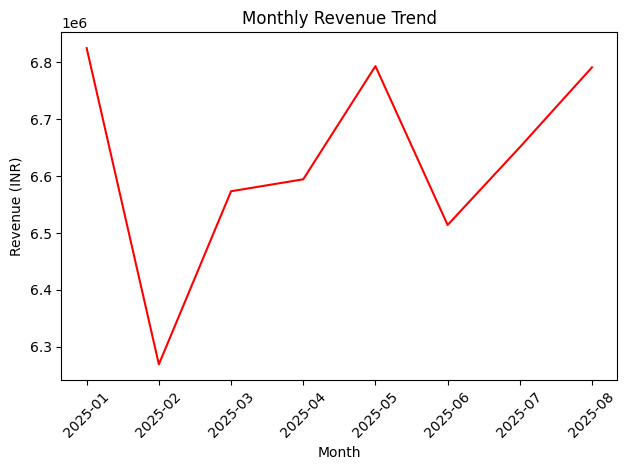

In [13]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['YearMonth'] = df['Order Date'].dt.to_period('M').astype(str)

monthly_revenue = df.groupby('YearMonth')['Price (INR)'].sum().reset_index()

plt.figure()
plt.plot(monthly_revenue['YearMonth'], monthly_revenue['Price (INR)'], color='red')
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Revenue (INR)')
plt.title('Monthly Revenue Trend')
plt.tight_layout()
plt.show()

##### Daily Sales Trend:

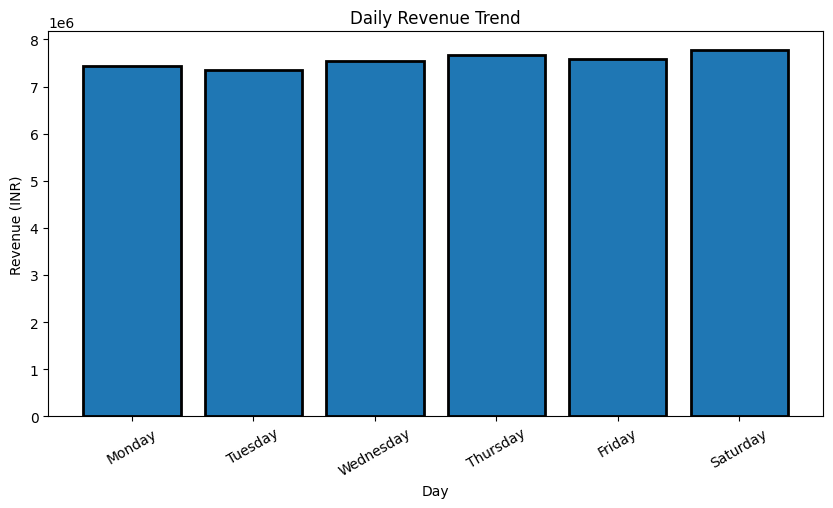

In [14]:
df['DayName'] = pd.to_datetime(df['Order Date']).dt.day_name()

daily_revenue = (
    df.groupby('DayName')['Price (INR)'].sum()
    .reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'])
)

plt.figure(figsize=(10, 5))
plt.bar(daily_revenue.index, daily_revenue.values, edgecolor='black', linewidth=2)
plt.xlabel('Day')
plt.ylabel('Revenue (INR)')
plt.title('Daily Revenue Trend')
plt.xticks(rotation=30)

plt.show()

##### Total Sales by Food Type(Veg vs Non-Veg):

In [15]:
non_veg_keywords = [
    'chicken', 'eggs', 'fish', 'mutton',
    'prawn', 'biriyani', 'kabab', 'kebab',
    'non-veg', 'non veg'
]

df['Food Category'] = np.where(
    df['Dish Name'].str.lower().str.contains('|'.join(non_veg_keywords), na=False),
    'Non-Veg',
    'Veg'
)

In [16]:
food_revenue = (
    df.groupby('Food Category')['Price (INR)']
    .sum()
    .reset_index()
)
print(food_revenue.head())

  Food Category  Price (INR)
0       Non-Veg  16232722.36
1           Veg  36779783.41


In [17]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"

fig = px.pie(
    food_revenue,
    values='Price (INR)',
    names='Food Category',
    hole=0.5,
    title='Revenue Contribution: Veg vs Non-Veg',
)

fig.update_traces(
    textinfo='percent+label',
    pull=(0.05, 0)
)

fig.update_layout(
    height=500,
    margin=dict(t=60, b=40, l=40, r=40)
)

fig.show()

##### Total Sales by State:

In [18]:
fig = px.bar(
    df.groupby("State", as_index=False)["Price (INR)"].sum()
     .sort_values('Price (INR)', ascending=False),
    x='Price (INR)',
    y='State',
    orientation='h',
    title='Revenue by State (INR)'
)

fig.update_layout(height=600, yaxis=dict(autorange='reversed'))
fig.show()

##### Quarterly Performance Summary:

In [26]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Quarter'] = df['Order Date'].dt.to_period('Q').astype(str)

quarterly_summary = (
    df.groupby('Quarter', as_index=False)
        .agg(
            Total_Sales=('Price (INR)', 'sum'),
            Avg_Ratings=('Rating', 'mean'),
            Total_Orders=('Order Date', 'count')
        )
        .sort_values('Quarter')
)

# quarterly_summary['Total_Sales'] = quarterly_summary['Total_Sales'].round(0)
# quarterly_summary['Avg_Ratings'] = quarterly_summary['Avg_Ratings'].round(2)

quarterly_summary

,Quarter,Total_Sales,Avg_Ratings,Total_Orders
0,2025Q1,19667821.77,4.342643,73096
1,2025Q2,19902256.59,4.340011,74163
2,2025Q3,13442427.41,4.342359,50171


##### Top 5 Cities by Sales:

In [28]:
top_5_cities = (
    df.groupby('City')['Price (INR)']
        .sum()
        .nlargest(5)
        .sort_values()
        .reset_index()
)

fig = px.bar(
    top_5_cities,
    x = 'Price (INR)',
    y = 'City',
    orientation='h',
    title='Top 5 Cities by Sales',
    color_discrete_sequence=['blue']
)

fig.show()

##### Weekly Trend Analysis:

In [33]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['YearWeek'] = df['Order Date'].dt.strftime('%b') + '-W' + df['Order Date'].dt.isocalendar().week.astype(str)

weekly_revenue = (
    df.groupby('YearWeek', as_index=False)['Price (INR)']
        .sum()
        .sort_values('YearWeek')
)

weekly_revenue

,YearWeek,Price (INR)
0,Apr-W14,1293168.52
1,Apr-W15,1551114.39
2,Apr-W16,1544439.18
3,Apr-W17,1535155.98
4,Apr-W18,670636.93
5,Aug-W31,680840.10
6,Aug-W32,1558098.72
7,Aug-W33,1497733.59
8,Aug-W34,1548112.71
9,Aug-W35,1506676.78


In [35]:
fig = px.line(
    weekly_revenue,
    x='YearWeek',
    y='Price (INR)',
    title='Weekly Revenue Trend',
    markers=True
)

fig.show()